<a href="https://colab.research.google.com/github/jaworskamalgorzata99-GIT/Maching-Learning-Bootcamp/blob/main/Book/Mieszkania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# os - Biblioteka systemowa — pozwala Pythonowi pracować z systemem operacyjnym.
# tarfile - Obsługuje archiwa .tar, .tar.gz (tgz), czyli skompresowane paczki plików (podobnie jak ZIP).
# urllib (dokładnie urllib.request) - Biblioteka do pobierania danych z internetu.

import os
import tarfile
import urllib

# DOWNLOAD_ROOT → adres repozytorium (github raw)
# HOUSING_PATH → lokalny folder, do którego zapiszesz dane - HOUSING_PATH mówi, gdzie lokalnie zapisać pobrane dane.
# HOUSING_URL → pełny URL pliku .tgz (archiwum z danymi) - HOUSING_URL to miejsce w internecie, skąd pobieramy plik.
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("zestawy danych", "mieszkania")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Funkcja, która:
# pobiera plik TGZ z internetu
# zapisuje go lokalnie
# rozpakowuje jego zawartość

def fetch_housing_data(housing_url = HOUSING_URL, housing_path = HOUSING_PATH):
  # Tworzenie folderu, jeśli go nie ma
  os.makedirs(housing_path, exist_ok = True)
  # tgz_path → lokalna ścieżka do pliku, który zapiszesz
  # urlretrieve(url, filename) → pobiera plik z internetu i zapisuje jako housing.tgz
  tgz_path = os.path.join(housing_path, "housing.tgz")
  urllib.request.urlretrieve(housing_url, tgz_path)

  # tarfile.open() → otwiera archiwum .tgz
  # extractall() → rozpakowuje wszystkie pliki do folderu housing_path
  # close() → zamyka archiwum

  housing_tgz = tarfile.open(tgz_path)
  housing_tgz.extractall(path=housing_path)
  housing_tgz.close()

In [2]:
# Ten folder istnieje tylko w czasie trwania sesji Colab - wirtualnie
# Po restarcie środowiska zniknie
# Jeśli chcesz go zachować, musisz skopiować do Google Drive

print(os.path.abspath(HOUSING_PATH))

/content/zestawy danych/mieszkania


In [3]:
import pandas as pd

def load_housing_data(housing_path = HOUSING_PATH):
  csv_path = os.path.join(housing_path, "housing.csv")
  return pd.read_csv(csv_path)

In [4]:
fetch_housing_data()
housing = load_housing_data()
housing.head()

/tmp/ipython-input-3082241628.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [7]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


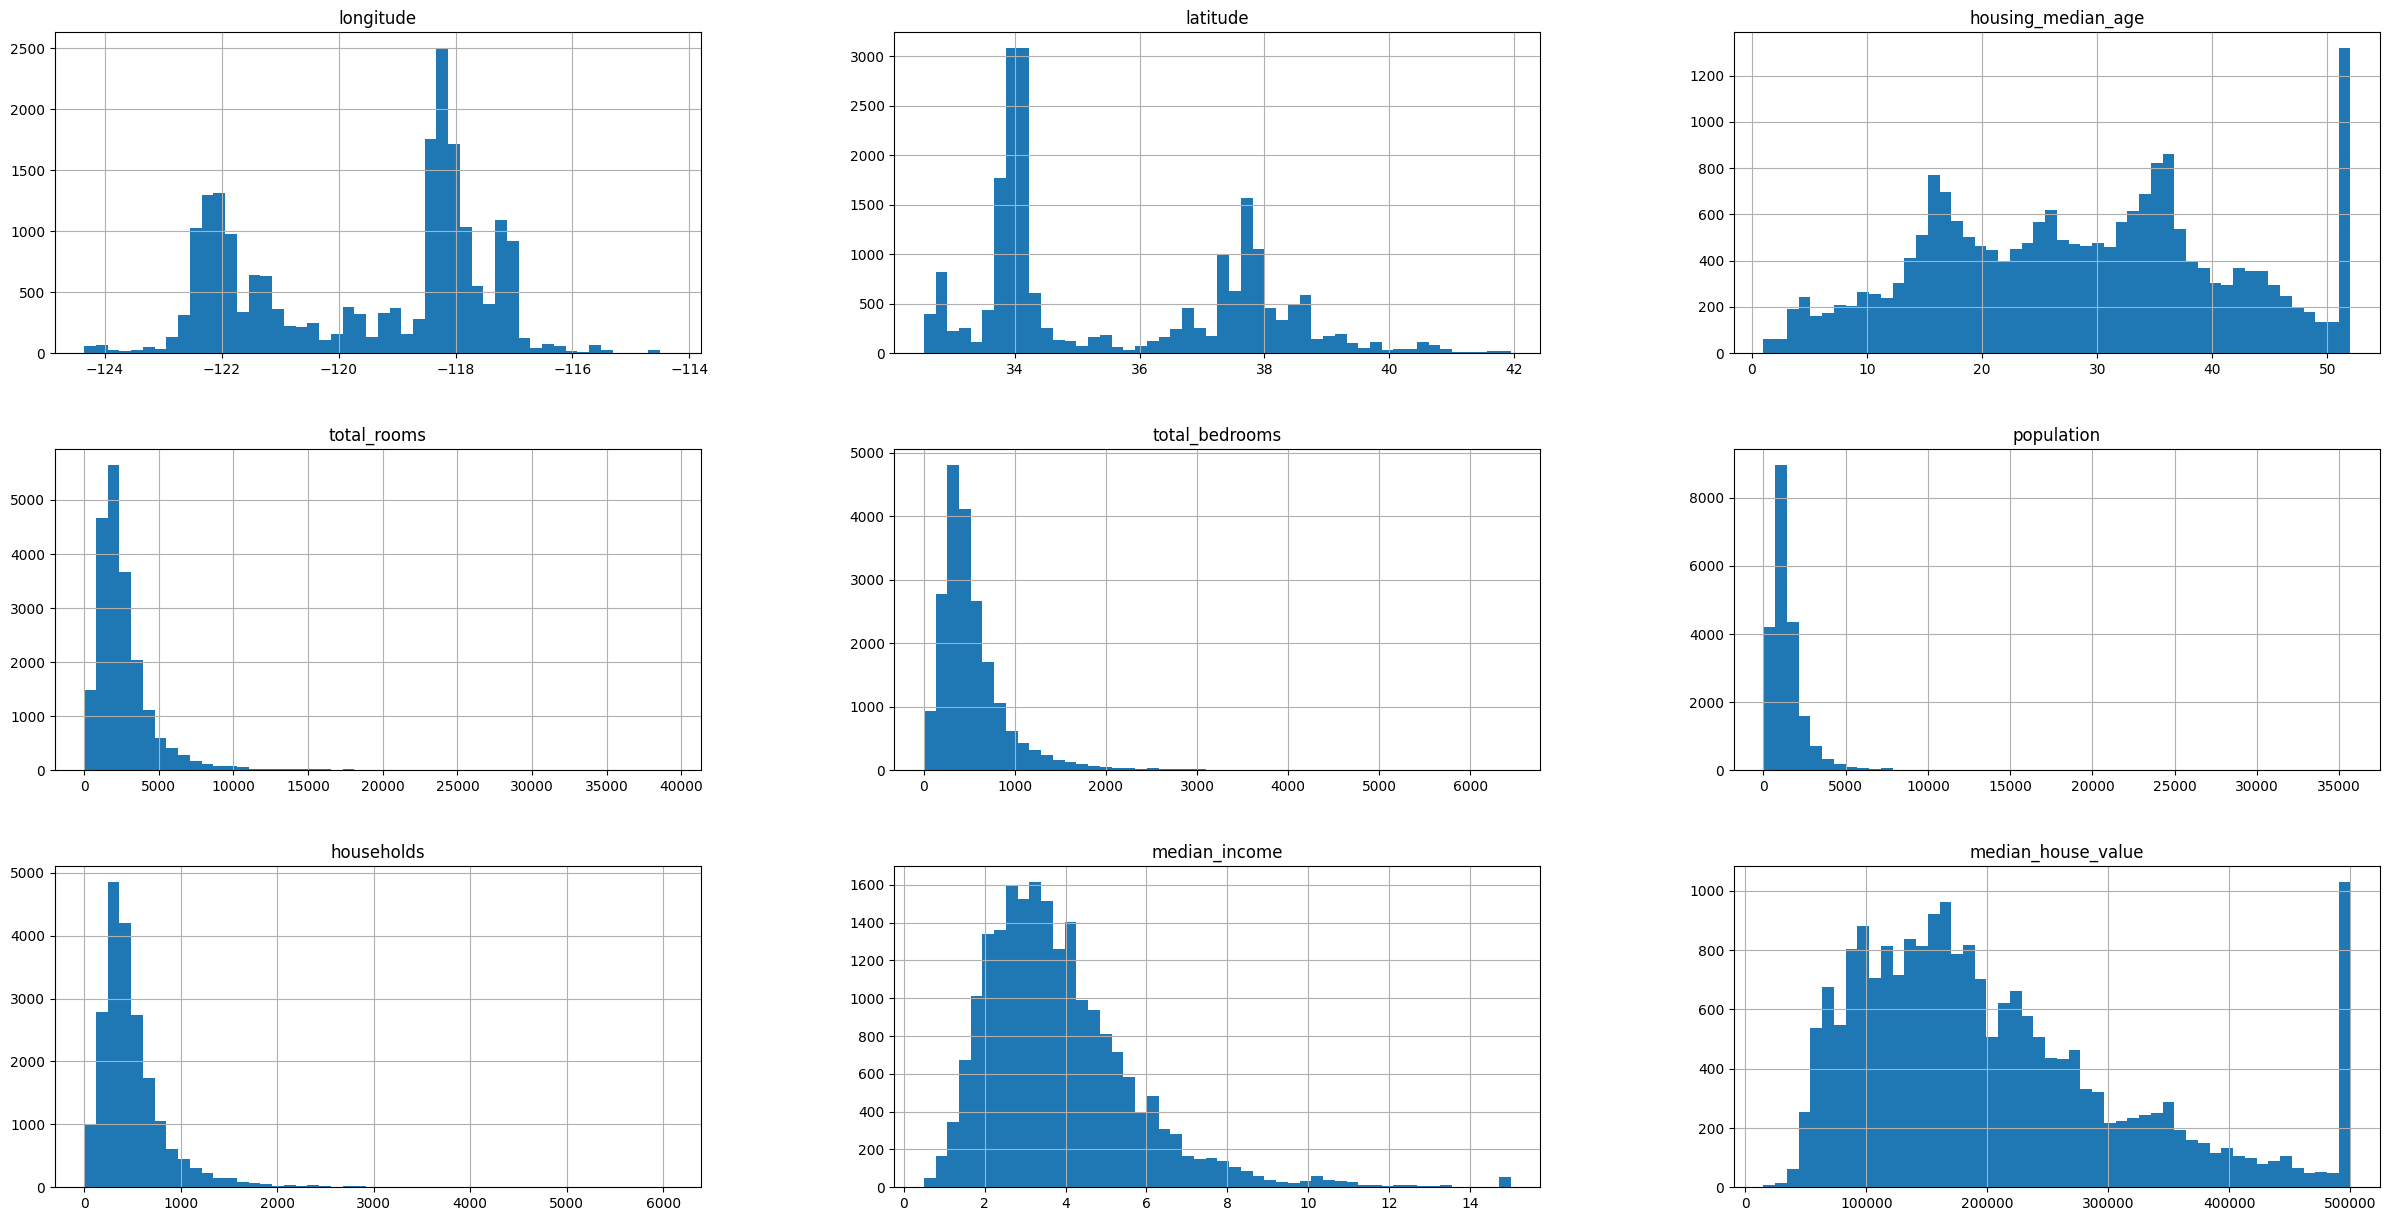

In [8]:
# %matplotlib inline # wyłącznie w notatniku Jupiter
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(30,15))
plt.show()

np.random.permutation(n)
Tworzy tablicę liczb od 0 do n–1, ale w losowej kolejności.

np.random.permutation(5)
może zwrócić np.:

array([3, 1, 4, 0, 2])
–– to jest losowa permutacja.

In [9]:
import numpy as np

def split_train_test(data, test_ratio):
  shuffled_indices = np.random.permutation(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [10]:
train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set), len(test_set))

16512 4128


Metoda	Bezpieczna?	Stabilna?	Używan w realnym ML?

dzielenie [:2, 2:]	❌ NIE	❌ NIE	❌ NIE

dzielenie po kolejności	❌ NIE	❌ NIE	❌ NIE

dzielenie losowe (train_test_split)	✔ TAK	❌ NIE	✔ (dla małych projektów)

dzielenie stabilne CRC32	✔ TAK	✔ TAK	⭐ TAK – profesjonalne projekty, produkcja

CRC32 zachowuje się jak „pseudolosowa funkcja” indeksu

Hash nie zależy liniowo od wartości ID.

CRC32 miesza dane tak, że wyjściowy hash wygląda jak liczba losowa.

CRC32 nie faworyzuje najmniejszych indeksów.
Dla kolejnych ID hash wygląda jak liczba wyciągnięta z kapelusza.

Dlatego:

losowość = ✔

brak biasu = ✔

stabilność podziału = ✔

powtarzalność = ✔

CRC32 jest super do stabilnego podziału train/test.

CRC32 służy do:

sprawdzania integralności danych (czy coś nie zostało uszkodzone),

tworzenia szybkiego, stabilnego skrótu liczby lub tekstu,

tworzenia deterministycznego podziału danych na train/test (jak w Twoim kodzie).

train_test_split — dobre do nauki, prototypów, małych projektów
ID-based split (CRC32) — dobre do poważnych projektów, produkcji, analizy

In [11]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
  return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * (2**32)

def split_train_test_by_id(data, test_ratio, id_column):
  ids = data[id_column]
  in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
  return data.loc[~in_test_set], data.loc[in_test_set]

Housing nie zawiera kolumny z identyfikatorami więc wykorzystujemy indeks wiersza

In [12]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing_with_id = housing.reset_index() # dodaje kolumnę index
housing_with_id.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [15]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [16]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [17]:
housing['income_cat'] = pd.cut(housing["median_income"],
                               bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels = [1,2,3,4,5])

<Axes: >

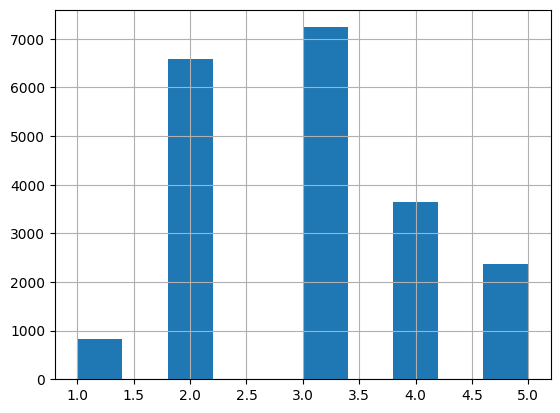

In [18]:
housing['income_cat'].hist()

StratifiedShuffleSplit to ulepszona wersja train_test_split, która utrzymuje proporcje kategorii w zbiorze treningowym i testowym.

To się nazywa stratyfikacja.

split.split(X, y)
X = pełne dane (housing)
y = kolumna kategorii (income_cat), według której utrzymujemy proporcje


Stratyfikacja pilnuje, aby te same procenty znalazły się w train i test.
split.split(...) zwraca:

train_index — numery wierszy do zbioru treningowego
test_index — numery wierszy do zbioru testowego

In [19]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]

In [20]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [21]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

,count
income_cat,
3,0.350594
2,0.318859
4,0.176296
5,0.114462
1,0.039789


In [22]:
# usnięcie atrybutu income_cat - przywrócenie do pierwotnego stanu

for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [23]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

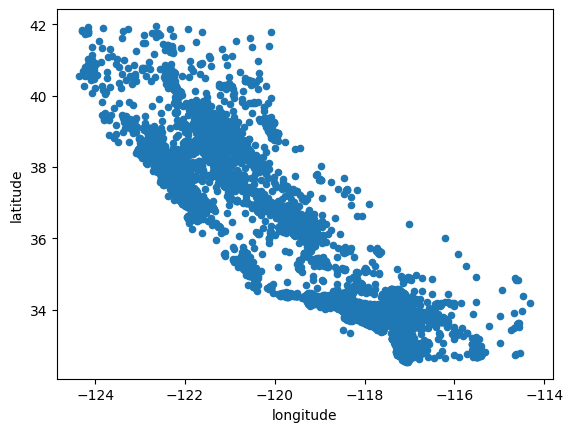

In [24]:
housing.plot(kind='scatter', x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

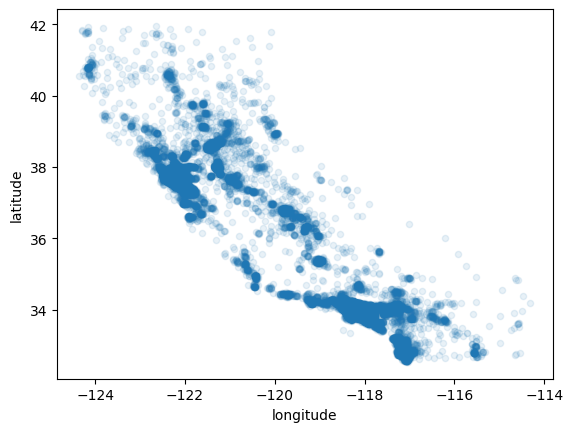

In [25]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1)

In [26]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


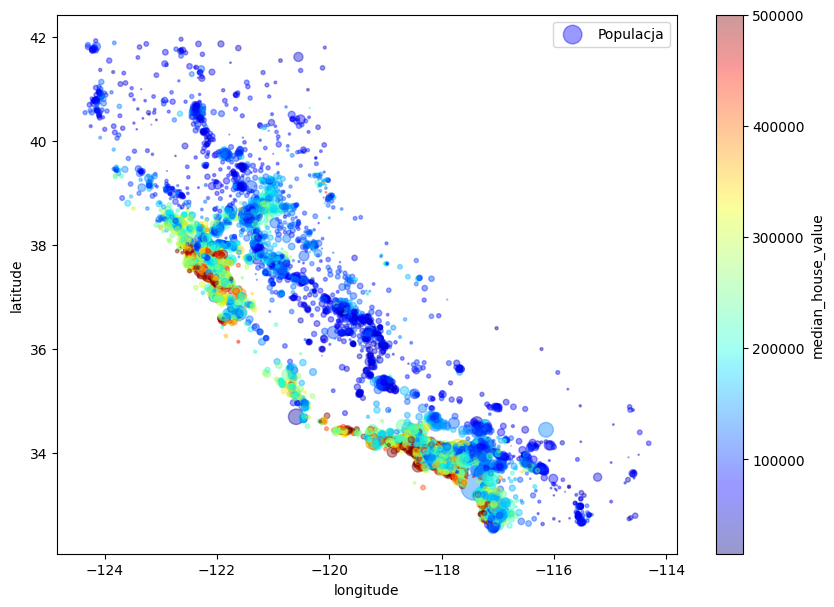

In [27]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             # promien kółka symbolizujący populację dystryktu - (s)
             s = housing['population']/100, label = 'Populacja', figsize = (10,7),
             # ceny mieszkań kolory - opcja (c)  - domyślna mapa kolorów - opcja (cmap) o nazwie jet)
             c = 'median_house_value', cmap = plt.get_cmap("jet"), colorbar=True, )
plt.legend()

In [28]:
corr_matrix = housing.corr(numeric_only=True)

In [29]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


In [30]:
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population,-0.026882
longitude,-0.047466
latitude,-0.142673


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

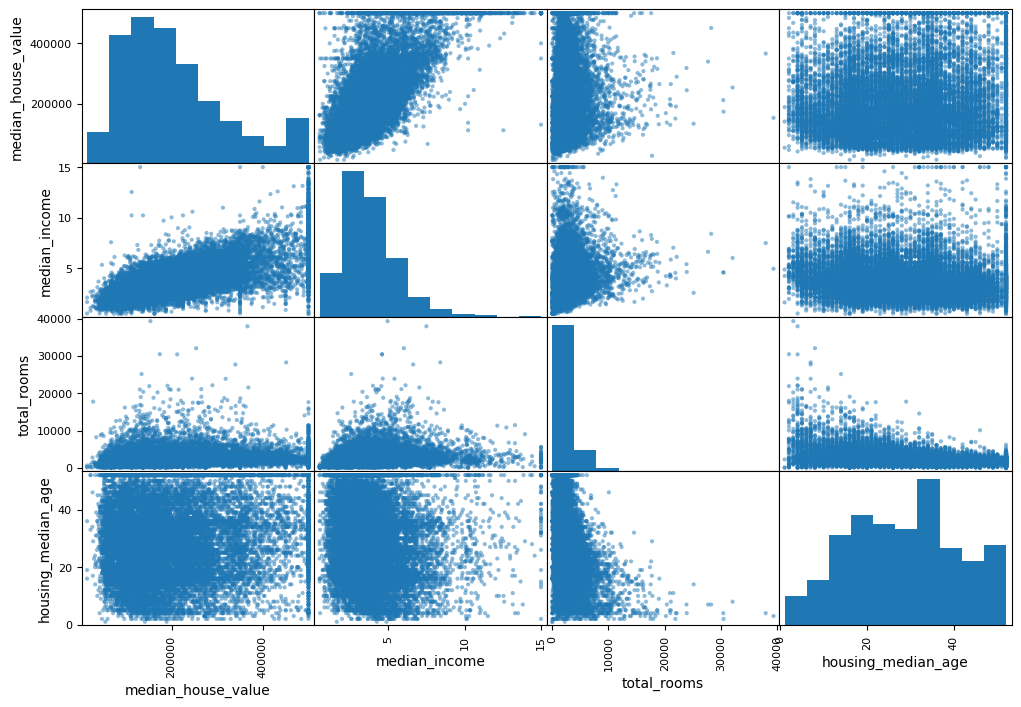

In [31]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms',
              'housing_median_age']
scatter_matrix (housing[attributes], figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

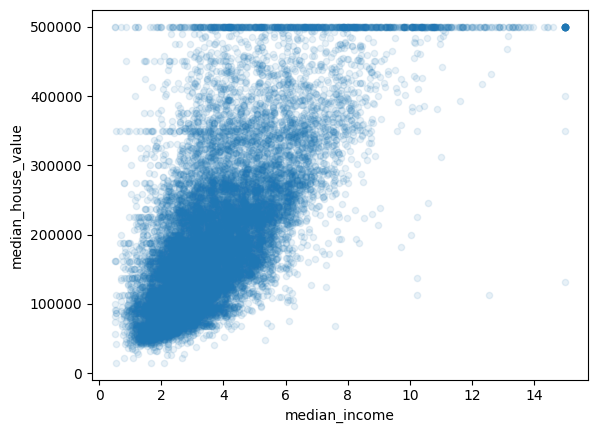

In [32]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1)

In [33]:
# średnia liczba pokoi na gospodarstwo domowe
housing['Pokoje_na_rodzine'] = housing['total_rooms'] / housing['households']
# odsetek pokoi, które są sypialniami
housing['Sypialnie_na_pokoje'] = housing['total_bedrooms'] /housing['total_rooms']
# średnia liczba osób w jednym gospodarstwie domowym
housing['Populacje_na_rodzine'] = housing['population'] / housing['households']

In [34]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
Pokoje_na_rodzine,0.146255
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
Populacje_na_rodzine,-0.021991
population,-0.026882
longitude,-0.047466


In [35]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [36]:
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace = True)

/tmp/ipython-input-2484130993.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace = True)


In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# SimpleImputer działa tylko na wartościach numerycznych, więc:
housing_num = housing.drop("ocean_proximity", axis=1)

imputer.fit(housing_num)

imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [38]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [39]:
housing_num.median()

,0
longitude,-118.51000
latitude,34.26000
housing_median_age,29.00000
total_rooms,2119.00000
total_bedrooms,433.00000
population,1164.00000
households,408.00000
median_income,3.54155


In [40]:
X = imputer.transform(housing_num)
X

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [41]:
housing_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index)
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [42]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [43]:
#housing_cat = housing['ocean_proximity']
#housing_cat

In [44]:
#type(housing_cat)

In [45]:
housing_cat = housing[['ocean_proximity']]
housing_cat

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
...,...
15174,<1H OCEAN
12661,INLAND
19263,<1H OCEAN
19140,<1H OCEAN


In [46]:
type(housing_cat)

pandas.core.frame.DataFrame

In [47]:
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [48]:
# Przekształcenie kategorii z tekstu na wartości numeryczne
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

#housing_cat_encoded.head() # head() is not available for numpy arrays, only for pandas objects

In [49]:
# Przekształcenie kategorii z tekstu na wartości numeryczne
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

#housing_cat_encoded.head() # head() is not available for numpy arrays, only for pandas objects
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [50]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [51]:
# powyższe rozwiązanie nie najlepsze bo nie jest to kategoria którą łatwo uporządkować jak bardzo dobry, dobry, zły
# tutaj lepszym rozwiązaniem będzie OneHotEncoding - zmienne binarne na wszystkie-1 kategorie

In [52]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot
# uzyskujemy macierz rzadką - zapisuje same '1'

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [53]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [54]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [55]:
# Niestandardowe transformatory - własne
# Wystarczy stworzyć trzy metody: fit(), transform(), fit_transform() - ją możemy uzyskać dodając klasę bazową TransformerMixin
# Dodając klasę bazową BaseEstimator - uzyskuje jeszcze dostęp do metod:  get_params() i set_params() - do automatycznego strojenia parametrów

In [56]:
#housing

housing.values

array([[-121.46, 38.52, 29.0, ..., 706.0, 2.1736, 'INLAND'],
       [-117.23, 33.09, 7.0, ..., 768.0, 6.3373, 'NEAR OCEAN'],
       [-119.04, 35.37, 44.0, ..., 300.0, 2.875, 'INLAND'],
       ...,
       [-122.72, 38.44, 48.0, ..., 172.0, 3.1797, '<1H OCEAN'],
       [-122.7, 38.31, 14.0, ..., 501.0, 4.1964, '<1H OCEAN'],
       [-122.14, 39.97, 27.0, ..., 197.0, 3.1319, 'INLAND']], dtype=object)

In [57]:
# Dodanie cech

from sklearn.base import BaseEstimator, TransformerMixin

# To są numericzne indeksy kolumn w macierzy housing.values.
# indeks	kolumna
# 3	      total_rooms
# 4	      total_bedrooms
# 5	      population
# 6	      households
rooms_ix, bedrooms_ix, population_ix, households_ix = 3,4,5,6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  #To pozwala włączyć lub wyłączyć jedną cechę: sypialnie / pokoje.
  def __init__(self, add_bedrooms_per_room = True): # Żadnych zmiennych *args ani **kargs
    self.add_bedrooms_per_room = add_bedrooms_per_room
  def fit(self, X, y=None):
    return self # Nic nie robi — tylko zwraca siebie. (To normalne w transformerach, które nie wymagają uczenia.)

  #Obliczanie nowych kolumn
  def transform(self, X):
    Pokoje_na_rodzine = X[:, rooms_ix] / X[:, households_ix]
    Populacja_na_rodzine = X[:, population_ix] / X[:, households_ix]
    if self.add_bedrooms_per_room:
      Sypialnie_na_pokoje = X[:, bedrooms_ix] / X[:, rooms_ix]
      #
      return np.c_[X, Pokoje_na_rodzine, Populacja_na_rodzine, Sypialnie_na_pokoje]
    else:
      return np.c_[X, Pokoje_na_rodzine, Populacja_na_rodzine]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [58]:
housing_extra_attribs

array([[-121.46, 38.52, 29.0, ..., 'INLAND', 5.485835694050992,
        3.168555240793201],
       [-117.23, 33.09, 7.0, ..., 'NEAR OCEAN', 6.927083333333333,
        2.6236979166666665],
       [-119.04, 35.37, 44.0, ..., 'INLAND', 5.3933333333333335,
        2.223333333333333],
       ...,
       [-122.72, 38.44, 48.0, ..., '<1H OCEAN', 4.1104651162790695,
        2.6627906976744184],
       [-122.7, 38.31, 14.0, ..., '<1H OCEAN', 6.297405189620759,
        2.411177644710579],
       [-122.14, 39.97, 27.0, ..., 'INLAND', 5.477157360406092,
        3.1725888324873095]], dtype=object)

In [59]:
# Skalowanie min-max - Normalizacja (0,1) - z scikit-learn MinMaxScaler - hiperparametr feature_range - pozwala zmienic zakres skalowania
# Standaryzacja - (dzielenie przez odchylenie) nie ma konkretnego zakresu - z scikit-learn - StandardScaler

In [60]:
# Potoki transformujące - klasa Pipeline - pomaga wyznaczyć odpowiednią sekwencję transformacji
# Wszystkie elementy oprócz ostatniego estymatora muszą być funkcjami przekształcającymi - muszą zawierać metodę fit_transform()
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# do zmiennych numerycznych
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]])

In [61]:
# ColumnTransformer - przetwarza wszystkie kolumny i dobiera odpowiednie transformacje do poszczególnych typów kolumn
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

In [62]:
# Trenowanie i ocena modelu za pomocą zbioru uczącego

In [63]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [64]:
some_data = housing.iloc[:5]
housing.iloc[:5]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


In [65]:
some_labels = housing_labels.iloc[:5]
housing_labels.iloc[:5]

,median_house_value
12655,72100.0
15502,279600.0
2908,82700.0
14053,112500.0
20496,238300.0


In [66]:
some_data_prepared = full_pipeline.transform(some_data)
some_data_prepared

array([[-0.94135046,  1.34743822,  0.02756357,  0.58477745,  0.64037127,
         0.73260236,  0.55628602, -0.8936472 ,  0.01739526,  0.00622264,
        -0.12112176,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.17178212, -1.19243966, -1.72201763,  1.26146668,  0.78156132,
         0.53361152,  0.72131799,  1.292168  ,  0.56925554, -0.04081077,
        -0.81086696,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, -0.46977281, -0.54513828,
        -0.67467519, -0.52440722, -0.52543365, -0.01802432, -0.07537122,
        -0.33827252,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.22173797, -1.35147437, -0.37006852, -0.34865152, -0.03636724,
        -0.46761716, -0.03729672, -0.86592882, -0.59513997, -0.10680295,
         0.96120521,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.43743108, -0.63581817, -0

In [67]:
print("Prognozy:", lin_reg.predict(some_data_prepared))

Prognozy: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [68]:
print("Ektykiety:", list(some_labels))

Ektykiety: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [69]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [70]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [71]:
from sklearn.model_selection import cross_val_score
# funkcja sprawdzianu krzyżowego z Scikit-learn oczekuje funkcji użyteczność (im większa wartość tym lepiej)
# czyli przeciwieństwo błędu MSE - dlatego dodajemy minus

# scoring='neg_mean_squared_error' -scikit-learn chce, żeby większe wyniki były lepsze,
# a MSE jest „tym mniejsze, im lepsze”,
# więc scikit-learn zwraca ujemne MSE (czyli neg_mean_squared_error).

scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring = 'neg_mean_squared_error', cv=10)

#masz ujemne MSE → -scores daje dodatnie MSE
#pierwiastkujesz → dostajesz RMSE
tree_rmse_scores = np.sqrt(-scores)

In [75]:
def display_scores(scores):
  print("Wyniki:", scores)
  print("Średnia:", scores.mean())
  print("Odchylenie standardowe:", scores.std())

display_scores(tree_rmse_scores)

Wyniki: [72136.50752622 69520.77168502 69482.10384247 73865.89202088
 70890.56984244 78680.70676023 70667.85290157 73954.92322827
 67507.65718851 70240.59825027]
Średnia: 71694.75832458794
Odchylenie standardowe: 2996.5061971574764


Wychodzi nawet gorzej niż w regresji liniowej - wynik uzuskany za pomocą sprawdzianu krzyżowego: 71 407 +/- 2 439

In [77]:
# Sprawdzian krzyżowy dla modelu regresji liniowej:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

display_scores(lin_rmse_scores)

Wyniki: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Średnia: 69104.07998247063
Odchylenie standardowe: 2880.3282098180694


Model drzewa decyzyjnego ulega tak silnemu przetrenowaniu, że osiąga gorsze wyniki od modelu regrsji liniowej


In [82]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=42)

In [83]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(18650.698705770003)

Jest lepiej - model wygląda obiecująco ale wciąz wynik dla zestawu uczacego jest mniejszy niz dla zbiorow walidacyjnych, co oznacza ze model caly czas ulega przetrenowaniu

In [84]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Wyniki: [51559.63379638 48737.57100062 47210.51269766 51875.21247297
 47577.50470123 51863.27467888 52746.34645573 50065.1762751
 48664.66818196 54055.90894609]
Średnia: 50435.58092066179
Odchylenie standardowe: 2203.3381412764606


joblib.dump → zapisuje model do pliku
joblib.load → wczytuje zapisany model

To pozwala:

zachować model bez ponownego trenowania

przenosić model między komputerami

ładować model po tygodniu / miesiącu / roku

używać go w aplikacjach produkcyjnych

In [86]:
# Zapisanie modeli

import joblib

joblib.dump(lin_reg, "moj_model.pkl")
# a póżniej...
my_model_loaded = joblib.load("moj_model.pkl")

SVR to wersja regresji z rodziny SVM (Support Vector Machines).

W klasycznej regresji próbujesz dopasować linię jak najbliżej punktów.
A SVR działa odwrotnie:

👉 stara się znaleźć linię, która ignoruje większość punktów, dopóki mieszczą się one w pewnym „tunelu tolerancji”.

Ten tunel nazywa się epsilon (ε).

In [90]:
from sklearn.svm import SVR

svm_reg = SVR(kernel='linear')
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

np.float64(111095.06635291968)

Wyregulowanie modelu - Metoda Przeszukiwania Siatki

In [91]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # sprawdza 12 (3x4) kombinacji hiperparametró
    {'n_estimators': [3,10,30], 'max_features': [2,4,6,8]},
    # następnie sprawdza 6 (2x3) kombinacji z wyłączonym parametrem bootstrap (False)
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2,3,4]},
]

forest_reg = RandomForestRegressor(random_state=42)
# przeprowadza proces uczenia na pięciu podzbiorach, czyli łącznie (12+6)*5=90 przebiegów
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

n_estimators	liczba drzew	więcej → stabilniejszy model, wolniejsze trenowanie

max_features	liczba cech losowanych przy każdym podziale	mniejsza liczba → większa losowość → mniejszy overfitting

bootstrap	czy losujemy próbki z powtórzeniami	True = standardowy Random Forest

In [93]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [96]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)

In [98]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
  print(np.sqrt(-mean_score), params)

# 18 rekordów

63895.161577951665 {'max_features': 2, 'n_estimators': 3}
54916.32386349543 {'max_features': 2, 'n_estimators': 10}
52885.86715332332 {'max_features': 2, 'n_estimators': 30}
60075.3680329983 {'max_features': 4, 'n_estimators': 3}
52495.01284985185 {'max_features': 4, 'n_estimators': 10}
50187.24324926565 {'max_features': 4, 'n_estimators': 30}
58064.73529982314 {'max_features': 6, 'n_estimators': 3}
51519.32062366315 {'max_features': 6, 'n_estimators': 10}
49969.80441627874 {'max_features': 6, 'n_estimators': 30}
58895.824998155826 {'max_features': 8, 'n_estimators': 3}
52459.79624724529 {'max_features': 8, 'n_estimators': 10}
49898.98913455217 {'max_features': 8, 'n_estimators': 30}
62381.765106921855 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54476.57050944266 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59974.60028085155 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52754.5632813202 {'bootstrap': False, 'max_features': 3, 'n_estimators': 1

In [103]:
grid_search.cv_results_['mean_test_score']

array([-4.08259167e+09, -3.01580263e+09, -2.79691494e+09, -3.60904984e+09,
       -2.75572637e+09, -2.51875938e+09, -3.37151349e+09, -2.65424040e+09,
       -2.49698135e+09, -3.46871820e+09, -2.75203022e+09, -2.48990912e+09,
       -3.89148462e+09, -2.96769673e+09, -3.59695268e+09, -2.78304395e+09,
       -3.34444030e+09, -2.62947213e+09])

In [107]:
import numpy as np
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

# Przeliczamy neg_MSE → RMSE
results["rmse_test"] = np.sqrt(-results["mean_test_score"])
results["rmse_train"] = np.sqrt(-results["mean_train_score"])

# Wybieramy i sortujemy wyniki
rmse_table = results[[
    "params",
    "rmse_test",
    "rmse_train",
    "std_test_score"
]].sort_values(by="rmse_test")

rmse_table

,params,rmse_test,rmse_train,std_test_score
11,"{'max_features': 8, 'n_estimators': 30}",49898.989135,19521.531601,7.086483e+07
8,"{'max_features': 6, 'n_estimators': 30}",49969.804416,19562.671288,7.357046e+07
5,"{'max_features': 4, 'n_estimators': 30}",50187.243249,19641.467005,8.488084e+07
17,"{'bootstrap': False, 'max_features': 4, 'n_estimators': 10}",51278.378771,-0.000000,8.510266e+07
7,"{'max_features': 6, 'n_estimators': 10}",51519.320624,22457.055965,6.967978e+07
10,"{'max_features': 8, 'n_estimators': 10}",52459.796247,22579.696207,6.258030e+07
4,"{'max_features': 4, 'n_estimators': 10}",52495.012850,22741.879229,1.182604e+08
15,"{'bootstrap': False, 'max_features': 3, 'n_estimators': 10}",52754.563281,-0.000000,8.862580e+07
2,"{'max_features': 2, 'n_estimators': 30}",52885.867153,20940.410082,7.980892e+07
13,"{'bootstrap': False, 'max_features': 2, 'n_estimators': 10}",54476.570509,13.784984,4.582448e+07


BŁĄD RMSE NAJNIZSZY! - Dostroiliśmy nasz najlepszy model

In [99]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.152903,0.018355,0.007630,0.000829,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-4.119912e+09,-3.723465e+09,...,-4.082592e+09,1.867375e+08,18,-1.155630e+09,-1.089726e+09,-1.153843e+09,-1.118149e+09,-1.093446e+09,-1.122159e+09,2.834288e+07
1,0.565504,0.032702,0.025503,0.010750,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-2.973521e+09,-2.810319e+09,...,-3.015803e+09,1.139808e+08,11,-5.982947e+08,-5.904781e+08,-6.123850e+08,-5.727681e+08,-5.905210e+08,-5.928894e+08,1.284978e+07
2,1.391216,0.308067,0.041707,0.004708,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.801229e+09,-2.671474e+09,...,-2.796915e+09,7.980892e+07,9,-4.412567e+08,-4.326398e+08,-4.553722e+08,-4.320746e+08,-4.311606e+08,-4.385008e+08,9.184397e+06
3,0.197340,0.002056,0.005492,0.000103,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.528743e+09,-3.490303e+09,...,-3.609050e+09,1.375683e+08,16,-9.782368e+08,-9.806455e+08,-1.003780e+09,-1.016515e+09,-1.011270e+09,-9.980896e+08,1.577372e+07
4,0.632544,0.003671,0.013910,0.000358,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.742620e+09,-2.609311e+09,...,-2.755726e+09,1.182604e+08,7,-5.063215e+08,-5.257983e+08,-5.081984e+08,-5.174405e+08,-5.282066e+08,-5.171931e+08,8.882622e+06
5,2.038581,0.213767,0.040053,0.003926,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.522176e+09,-2.440241e+09,...,-2.518759e+09,8.488084e+07,3,-3.776568e+08,-3.902106e+08,-3.885042e+08,-3.830866e+08,-3.894779e+08,-3.857872e+08,4.774229e+06
6,0.264914,0.004477,0.005620,0.000208,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.362127e+09,-3.311863e+09,...,-3.371513e+09,1.378086e+08,13,-8.909397e+08,-9.583733e+08,-9.000201e+08,-8.964731e+08,-9.151927e+08,-9.121998e+08,2.444837e+07
7,1.017864,0.165602,0.015352,0.001131,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.622099e+09,-2.669655e+09,...,-2.654240e+09,6.967978e+07,5,-4.939906e+08,-5.145996e+08,-5.023512e+08,-4.959467e+08,-5.147087e+08,-5.043194e+08,8.880106e+06
8,2.931528,0.301086,0.038259,0.001074,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.446142e+09,-2.446594e+09,...,-2.496981e+09,7.357046e+07,2,-3.760968e+08,-3.876636e+08,-3.875307e+08,-3.760938e+08,-3.861056e+08,-3.826981e+08,5.418747e+06
9,0.352995,0.012013,0.005933,0.000986,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.590333e+09,-3.232664e+09,...,-3.468718e+09,1.293758e+08,14,-9.505012e+08,-9.166119e+08,-9.033910e+08,-9.070642e+08,-9.459386e+08,-9.247014e+08,1.973471e+07


✔ GridSearchCV, kiedy:

hiperparametrów jest mało

zakres poszukiwań jest mały

masz duży budżet obliczeniowy




✔ RandomizedSearchCV, kiedy:

hiperparametrów jest dużo (RF, XGBoost, NN)

chcesz szybciej przeszukać duży obszar wartości

zależy Ci na efektywności

W praktyce:
RandomizedSearchCV jest używany częściej.

🔚 TL;DR – najkrócej:

GridSearchCV = dokładnie, ale wolno
RandomizedSearchCV = szybko, ale losowo (często wystarczająco dobrze lub lepiej)

GridSearchCV

sprawdza WSZYSTKIE możliwe kombinacje hiperparametrów

np. 3 × 4 × 5 = 60 modeli do trenowania

✔ pełne pokrycie
✖ bardzo wolne, szczególnie przy dużej liczbie parametrów

RandomizedSearchCV

losuje losowe kombinacje parametrów

np. powiesz mu: sprawdź 20 losowych modeli, zamiast 60 możliwych

✔ szybsze
✔ sprawdza większy zakres wartości
✔ idealne dla dużej liczby hiperparametrów
✖ nie gwarantuje znalezienia absolutnie najlepszego zestawu


GridSearchCV -Ustalasz całe siatki:
RandomizedSearchCV -Możesz podać rozkłady losowe

In [109]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'n_estimators': randint(low=1, high=200),
    'max_features': randint(low=1, high=8),
}

forest_reg = RandomForestRegressor(random_state=42)

rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5,
                                scoring='neg_mean_squared_error',
                                random_state=42)

rnd_search.fit(housing_prepared, housing_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4d30d2a8a0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4d30d2a0f0>},
                   random_state=42, scoring='neg_mean_squared_error')

In [110]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
  print(np.sqrt(-mean_score), params)

49117.55344336652 {'max_features': 7, 'n_estimators': 180}
51450.63202856348 {'max_features': 5, 'n_estimators': 15}
50692.53588182537 {'max_features': 3, 'n_estimators': 72}
50783.614493515 {'max_features': 5, 'n_estimators': 21}
49162.89877456354 {'max_features': 7, 'n_estimators': 122}
50655.798471042704 {'max_features': 3, 'n_estimators': 75}
50513.856319990606 {'max_features': 3, 'n_estimators': 88}
49521.17201976928 {'max_features': 5, 'n_estimators': 100}
50302.90440763418 {'max_features': 3, 'n_estimators': 150}
65167.02018649492 {'max_features': 5, 'n_estimators': 2}


49150.70756927707 {'max_features': 7, 'n_estimators': 180}

In [111]:
feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance

array([6.96542523e-02, 6.04213840e-02, 4.21882202e-02, 1.52450557e-02,
       1.55545295e-02, 1.58491147e-02, 1.49346552e-02, 3.79009225e-01,
       5.47789150e-02, 1.07031322e-01, 4.82031213e-02, 6.79266007e-03,
       1.65706303e-01, 7.83480660e-05, 1.52473276e-03, 3.02816106e-03])

In [112]:
np.set_printoptions(suppress=True)  # wyłącza notację naukową

In [113]:
feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance

array([0.06965425, 0.06042138, 0.04218822, 0.01524506, 0.01555453,
       0.01584911, 0.01493466, 0.37900922, 0.05477892, 0.10703132,
       0.04820312, 0.00679266, 0.1657063 , 0.00007835, 0.00152473,
       0.00302816])

In [115]:
extra_attribs = ['Pokoje_na_rodzine','Populacja_na_rodzine','Sypialnie_na_pokoje']

# named_transformers_['cat'] pobiera transformator używany dla
# kolumn kategorycznych - OneHotEncoder.
cat_encoder = full_pipeline.named_transformers_['cat']
# Pobranie nazw cech zakodowanych One-Hot
# full_pipeline = ColumnTransformer([
#     ("num", num_pipeline, num_attribs),
#     ("cat", OneHotEncoder(), cat_attribs),
# ])
cat_one_hot_attribs = list(cat_encoder.categories_[0])

attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importance, attributes), reverse =True)

[(np.float64(0.3790092248170967), 'median_income'),
 (np.float64(0.16570630316895876), 'INLAND'),
 (np.float64(0.10703132208204354), 'Populacja_na_rodzine'),
 (np.float64(0.06965425227942929), 'longitude'),
 (np.float64(0.0604213840080722), 'latitude'),
 (np.float64(0.054778915018283726), 'Pokoje_na_rodzine'),
 (np.float64(0.048203121338269206), 'Sypialnie_na_pokoje'),
 (np.float64(0.04218822024391753), 'housing_median_age'),
 (np.float64(0.015849114744428634), 'population'),
 (np.float64(0.015554529490469328), 'total_bedrooms'),
 (np.float64(0.01524505568840977), 'total_rooms'),
 (np.float64(0.014934655161887776), 'households'),
 (np.float64(0.006792660074259966), '<1H OCEAN'),
 (np.float64(0.0030281610628962747), 'NEAR OCEAN'),
 (np.float64(0.0015247327555504937), 'NEAR BAY'),
 (np.float64(7.834806602687504e-05), 'ISLAND')]

In [116]:
# Ocena systemu za pomocą zbioru testowgo - samo transform - bez fit!

In [118]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(47873.26095812988)

In [117]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)

95% przedziału ufności dla błędu uogólniania - scipy.stats.t.interval()

Statystyka (scipy.stats)
t.interval pochodzi z scipy.stats i służy do obliczania przedziału ufności dla rozkładu t-Studenta.

Obliczenie przedziału ufności dla RMSE (root mean squared error) modelu.

In [119]:
from scipy import stats

confidence = 0.95
# obliczenie błędów kwadratowych
squared_errors = (final_predictions - y_test) **2
# Obliczenie przedziału ufności dla średniej błędów kwadratowych
# confidence — poziom ufności
# len(squared_errors) - 1 — liczba stopni swobody (n − 1)
# loc=squared_errors.mean() — średnia (MSE)
# scale=stats.sem(squared_errors) — błąd standardowy średniej (standard error)

# Ponieważ pracowałeś na MSE, po obliczeniu przedziału bierzesz
# jego pierwiastek, aby otrzymać przedział ufności dla RMSE.

np.sqrt(stats.t.interval(confidence,
                         len(squared_errors) -1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

# mean() — chcemy oszacować średnią (MSE)
# sem() — potrzebujemy niepewności tej średniej
# n-1 — bo używamy statystyki t-Studenta, a ona wymaga df = n − 1

# loc oznacza wartość średnią (centrum) rozkładu,
# czyli gdzie jest „środek” tego, co modelujemy.

# scale to parametr skali, czyli rozciągnięcia rozkładu.
# To odpowiednik odchylenia standardowego (σ)
#  albo błędu standardowego — zależnie od kontekstu.

# stats.sem() oznacza standard error of the mean, po polsku:
# 👉 błąd standardowy średniej

array([45893.36082829, 49774.46796717])

Oznacza, że “z 95% pewnością błąd RMSE wynosi między ....